# Heat-Pump Hypothesis Tests

Two hypotheses tested on the **same synthetic-substation data** as
`HeatPumpDetection_clean.ipynb` (loaded from `data/substations_data.pkl`).
Each substation is an aggregation of households and is treated as an
**independent test unit**: every fit is done per substation, and the
hypotheses are evaluated across the whole population against a significance
level of **α = 0.05**.

1. **The (substation-level) simultaneity factor increases linearly with
   decreasing temperature.** Per substation, daily-mean `SF = HP_Load/HP_Peak`
   is linearly regressed on daily-mean temperature; the hypothesis holds for a
   substation if the slope is negative with p < 0.05.
2. **The R² of a hockey-stick fit of net load vs mean temperature decreases at
   higher temporal resolution.** Per substation, the hockey-stick fit is repeated
   at 15 min / 1 h / 8 h / daily; the R² distributions are compared with paired
   tests (Friedman omnibus + Wilcoxon signed-rank) against p < 0.05.

## Imports and data (controlled factorial design)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon, friedmanchisquare
from tqdm import tqdm

ALPHA = 0.05   # significance level for both hypotheses


In [2]:
# ---------------------------------------------------------------------------
# Substations come from the CONTROLLED FACTORIAL DESIGN (hp_design.py), not the
# old data/substations_data.pkl. The old generator drew hp_ratio ~ U(0.1, 1.0)
# and size ~ randint independently and sampled households WITH replacement,
# which (a) inflated SF -- a duplicated household is perfectly correlated with
# itself and contributes SF = 1 -- with a bias growing in N, manufacturing a
# spurious N-dependence in exactly the quantity H1 tests; (b) drew non-HP
# households from a different weather station than the temperature the load is
# regressed against; and (c) entangled N_hp with N_total.
#
# data/substations_data.pkl is left untouched -- the modelling notebooks use it.
# ---------------------------------------------------------------------------
import hp_design as hd

REGENERATE_DESIGN = False   # True re-runs the generator (~10 min, needs heapo)

if REGENERATE_DESIGN:
    design = hd.main()
else:
    design = hd.load_design()      # data/substations_design.pkl

meta = design['meta']
index = design['index']

# N_total / N_hp / hp_ratio are GROUND-TRUTH DESIGN VARIABLES used only to
# stratify and interpret results. They are never fed to a predictive model.
print(f"substations: {len(meta)}")
print(f"distinct households used: {design['n_distinct_households_used']} "
      f"of {design['n_distinct_households_available']} available")
print(f"timestamps: {len(index)} at "
      f"{(index[1] - index[0]).total_seconds() / 60:.0f} min resolution")
meta.drop(columns=['households', 'hp_households']).head()

# Task 4 (data collapse) uses a SECOND design on a re-spaced N grid. Only 58
# households carry a usable non-HP load series and the largest weather station
# holds 27, so N_total <= 27 is a hard ceiling: the main grid realises only
# N in {5, 10, 20}, giving a single (N_total, dt) coincidence -- not enough to
# test the N*dt collapse. The collapse design uses N in {4, 8, 16, 27}, which
# yields 4 coincident clusters at equal penetration grid and replicate count.
# Tasks 2 and 3 deliberately keep using the main design above.
design_collapse = hd.load_design(hd.COLLAPSE_DESIGN_PATH)
meta_collapse = design_collapse['meta']
print(f"collapse design: {len(meta_collapse)} substations, "
      f"N_total in {sorted(meta_collapse['N_total'].unique().tolist())}")


substations: 840
distinct households used: 54 of 58 available
timestamps: 35040 at 15 min resolution
collapse design: 1080 substations, N_total in [4, 8, 16, 27]


In [3]:
# Verification required before proceeding: coverage, decoupling of N_total and
# N_hp, existence of the zero-penetration controls, and the pseudo-replication
# audit (substations are drawn from a limited household pool).
hd.report_design(design)


COVERAGE TABLE (cells requested / filled / skipped)
 N_total  hp_ratio  N_hp  requested  filled  skipped                                                  reason
       5      0.00     0         40      40        0                                                        
       5      0.05     0         40      40        0                                                        
       5      0.10     0         40      40        0                                                        
       5      0.25     1         40      40        0                                                        
       5      0.50     2         40      40        0                                                        
       5      0.75     4         40      40        0                                                        
       5      1.00     5         40      40        0                                                        
      10      0.00     0         40      40        0                        

In [4]:
# ---------------------------------------------------------------------------
# The hockey-stick model, the shared constants and the data-hygiene helpers all
# come from hp_common.py -- the same definitions the detection notebook uses, so
# the two notebooks cannot drift apart.
#
# MIN_POINTS = 30 was replaced by `min_points_for_resolution`: a fixed point
# count means very different things at 15 min (~35 000 points/year) and daily
# (~365) resolution. The requirement is expressed in DAYS (MIN_HEATING_DAYS)
# and the point count derived per resampling rule, so every resolution demands
# the same span of real time.
# ---------------------------------------------------------------------------
from hp_common import (
    T_BALANCE_BOUNDS,
    HEATING_SEASON_THRESH,
    MIN_HEATING_DAYS,
    HDH_THRESH,
    hour_groups,
    hockey_stick,
    fit_hockey_stick,
    daily_mean_mean_heating_season,
    min_points_for_resolution,
    resolution_minutes,
)

for _rule in ['15min', '1h', '8h', 'D']:
    print(f'  {_rule:>5s}: dt = {resolution_minutes(_rule):6.0f} min  ->  '
          f'min points for {MIN_HEATING_DAYS} days = {min_points_for_resolution(_rule)}')

# Optional cap on the number of substations (None = use all). The 15-min fits in
# Hypothesis 2 are the slow part; set e.g. MAX_SUBS = 200 for a quick run.
MAX_SUBS = None

# H1 (SF) needs HP_Peak > 0 because SF = HP_Load / HP_Peak is undefined at zero
# penetration. The hp_ratio == 0 controls are kept in `control_ids` and are used
# for the net-load test and the Type I error check.
all_ids = meta.index.to_numpy()
sf_ids = meta.index[meta['HP_Peak'] > 0].to_numpy()      # SF is defined
control_ids = meta.index[meta['hp_ratio'] == 0.0].to_numpy()

if MAX_SUBS is not None and len(sf_ids) > MAX_SUBS:
    _rng = np.random.default_rng(42)
    sf_ids = _rng.choice(sf_ids, size=MAX_SUBS, replace=False)
    all_ids = np.union1d(sf_ids, control_ids)

print(f'{len(all_ids)} substations total | {len(sf_ids)} with SF defined | '
      f'{len(control_ids)} zero-penetration controls')


  15min: dt =     15 min  ->  min points for 20 days = 1920
     1h: dt =     60 min  ->  min points for 20 days = 480
     8h: dt =    480 min  ->  min points for 20 days = 60
      D: dt =   1440 min  ->  min points for 20 days = 20
840 substations total | 600 with SF defined | 120 zero-penetration controls


## Hypothesis 1 — does the simultaneity factor have a temperature THRESHOLD?

The previous version fitted one straight line per substation with
`linregress` and counted a negative slope with p < α as support. That tests
the wrong null: *slope ≠ 0* only establishes that the response reacts to
temperature at all, which is trivially true. The hypothesis is that the
response is **hockey-stick** — sloped below a balance temperature, flat above:

* `H0`: single straight line, `y = a + b·T`
* `H1`: hockey stick, `y = a + b·max(0, T_bal − T)`

Under `H0` the breakpoint `T_bal` is unidentified (the Davies problem), so the
likelihood-ratio statistic has no chi-squared null distribution — `scipy.stats.chi2`
and `scipy.stats.f` would both be invalid. The null is obtained by a
**residual bootstrap**, statistic `(RSS_lin − RSS_hock)/RSS_hock`, with
`p = (1 + #{stat_null ≥ stat_obs})/(n_boot + 1)`.

**Deviation from the brief, and why.** The specified *i.i.d.* residual bootstrap
is anti-conservative on this data: daily load residuals have a median lag-1
autocorrelation of ≈0.46, and resampling them independently makes the null
distribution too narrow. Measured on simulated data where `H0` is *true*, the
i.i.d. bootstrap rejects at 0.11 / 0.18 / 0.25 for AR(1) ρ = 0.3 / 0.6 / 0.8
instead of 0.05. A 30-day moving-block bootstrap restores calibration
(0.060 / 0.060 / 0.075) at no cost in power (1.000 against a true hockey stick).

The test is run twice: on **SF** (primary claim, `hp_ratio > 0` only, since SF is
undefined when the denominator is zero) and on **net load** (the deployable
case, *including* the zero-penetration controls).

In [5]:
import hp_h1 as h1

QUICK = False    # True -> N_BOOT_QUICK = 99 replicates for a development run
N_BOOT = h1.N_BOOT_QUICK if QUICK else h1.N_BOOT

# Per-substation results are cached incrementally, so an interrupted run
# resumes instead of refitting.
h1_sf = h1.run_h1(design, sf_ids, 'SF', n_boot=N_BOOT,
                  n_jobs=-1, chunk=150, block=h1.BLOCK_LEN)
h1_nl = h1.run_h1(design, all_ids, 'NetLoad', n_boot=N_BOOT,
                  n_jobs=-1, chunk=150, block=h1.BLOCK_LEN)

# Tidy long-format table on disk so the figures regenerate without refitting.
h1_results = pd.concat([h1_sf.assign(response='SF'),
                        h1_nl.assign(response='NetLoad')])
h1_results.to_parquet('data/h1_results_block.parquet')
print('saved data/h1_results_block.parquet', h1_results.shape)


resuming: 600 substations already cached in data/h1_cache\h1_SF_999_b30.pkl
SF: 0 substations to fit (999 bootstrap replicates each)
resuming: 840 substations already cached in data/h1_cache\h1_NetLoad_999_b30.pkl
NetLoad: 0 substations to fit (999 bootstrap replicates each)
saved data/h1_results_block.parquet (1440, 16)


In [6]:
# ---------------------------------------------------------------------------
# CONTROL CHECK FIRST. The zero-penetration substations contain no heat pump,
# so their rejection rate bounds the false-positive rate of the whole test.
# Everything else must be read against this floor, not against alpha.
#
# Note `hp_ratio == 0` under-counts the controls: cells such as
# (N_total=5, hp_ratio=0.05) round to N_hp = 0 and are also HP-free, so the
# true control set is N_hp == 0.
# ---------------------------------------------------------------------------
for label, sub in [('hp_ratio == 0', h1_nl[h1_nl.hp_ratio == 0]),
                   ('N_hp == 0 (true control set)', h1_nl[h1_nl.N_hp == 0])]:
    k, n = int(sub.reject.sum()), len(sub)
    lo, hi = h1.wilson(k, n)
    print(f'{label:30s} n={n:4d}  rejection={k/n:.3f}  95% Wilson CI [{lo:.3f}, {hi:.3f}]')

ctrl, withhp = h1_nl[h1_nl.N_hp == 0], h1_nl[h1_nl.N_hp >= 5]
print(f'\neffect size separates cleanly even where controls reject:')
print(f'  controls        statistic q50={ctrl.stat.median():.3f}  q90={ctrl.stat.quantile(.9):.3f}')
print(f'  HP substations  statistic q10={withhp.stat.quantile(.1):.3f}  q50={withhp.stat.median():.3f}')


hp_ratio == 0                  n= 120  rejection=0.125  95% Wilson CI [0.077, 0.196]
N_hp == 0 (true control set)   n= 240  rejection=0.167  95% Wilson CI [0.125, 0.219]

effect size separates cleanly even where controls reject:
  controls        statistic q50=0.010  q90=0.032
  HP substations  statistic q10=0.188  q50=0.569


In [7]:
# Rejection proportions with Wilson binomial CIs, stratified by penetration
# and by N_hp, plus the median T_bal (IQR) among rejecting substations.
for name, df in [('PRIMARY: SF vs daily mean temperature', h1_sf),
                 ('DEPLOYABLE: net load vs daily mean temperature', h1_nl)]:
    print('=' * 78); print(name); print('=' * 78)
    tab = h1.rejection_table(df, 'hp_ratio')
    print(tab.round(3).to_string(index=False))
    print('\nby N_hp:')
    print(h1.rejection_table(df, 'N_hp').round(3).to_string(index=False))
    print(f"\nDetection limit (lowest penetration with rejection > 80%): "
          f"{h1.detection_limit(tab)}\n")


PRIMARY: SF vs daily mean temperature
 hp_ratio   n  n_reject  reject_rate  ci_low  ci_high  tbal_median  tbal_q25  tbal_q75
     0.05  40        32        0.800   0.652    0.895        15.35    13.975      16.5
     0.10  80        68        0.850   0.756    0.912        16.00    15.150      16.9
     0.25 120       115        0.958   0.906    0.982        16.00    15.050      16.7
     0.50 120       117        0.975   0.929    0.991        16.10    15.300      16.6
     0.75 120       120        1.000   0.969    1.000        16.25    15.600      16.6
     1.00 120       120        1.000   0.969    1.000        16.40    15.900      16.7

by N_hp:
 N_hp   n  n_reject  reject_rate  ci_low  ci_high  tbal_median  tbal_q25  tbal_q75
    1 120        99        0.825   0.747    0.883         15.3    14.050    16.500
    2 120       113        0.942   0.884    0.971         16.0    14.900    16.900
    4  40        40        1.000   0.912    1.000         15.2    14.850    16.250
    5 120  

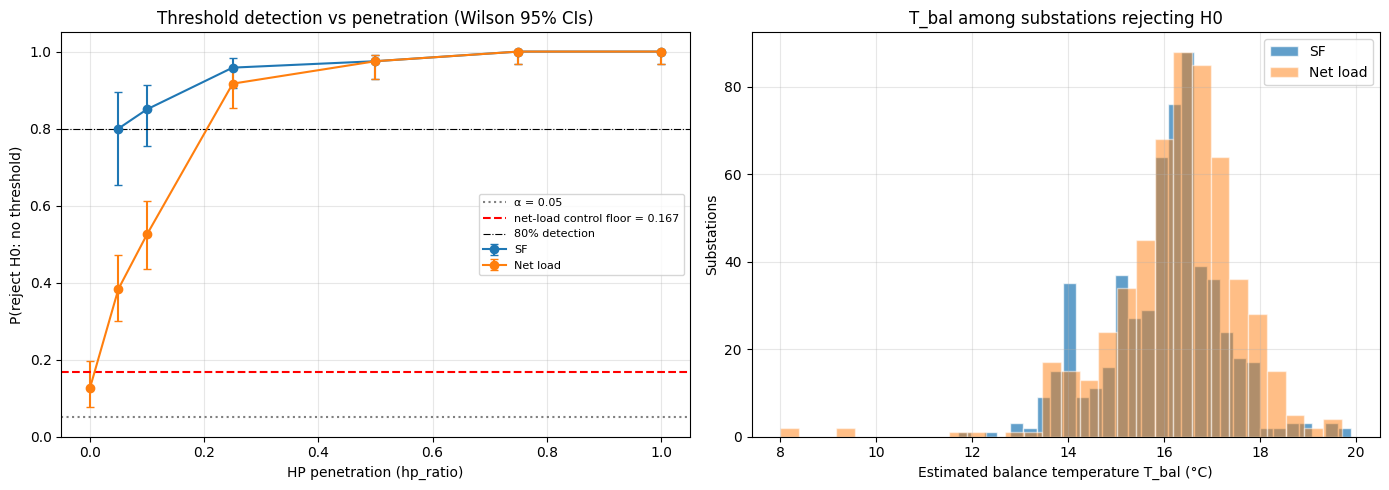

In [8]:
# Rejection rate vs penetration (with Wilson CIs) and the T_bal distribution.
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for df, label, colour in [(h1_sf, 'SF', 'tab:blue'),
                          (h1_nl, 'Net load', 'tab:orange')]:
    tab = h1.rejection_table(df, 'hp_ratio')
    err = np.vstack([tab.reject_rate - tab.ci_low, tab.ci_high - tab.reject_rate])
    axs[0].errorbar(tab.hp_ratio, tab.reject_rate, yerr=err, marker='o',
                    capsize=3, label=label, color=colour)
ctrl_rate = h1_nl[h1_nl.N_hp == 0].reject.mean()
axs[0].axhline(ALPHA, color='grey', ls=':', label=f'α = {ALPHA}')
axs[0].axhline(ctrl_rate, color='red', ls='--',
               label=f'net-load control floor = {ctrl_rate:.3f}')
axs[0].axhline(0.8, color='black', ls='-.', lw=.8, label='80% detection')
axs[0].set_xlabel('HP penetration (hp_ratio)')
axs[0].set_ylabel('P(reject H0: no threshold)')
axs[0].set_title('Threshold detection vs penetration (Wilson 95% CIs)')
axs[0].set_ylim(0, 1.05); axs[0].grid(alpha=.3); axs[0].legend(fontsize=8)

axs[1].hist(h1_sf.loc[h1_sf.reject, 't_bal'].dropna(), bins=30, alpha=.7,
            color='tab:blue', label='SF', edgecolor='white')
axs[1].hist(h1_nl.loc[h1_nl.reject & (h1_nl.N_hp > 0), 't_bal'].dropna(), bins=30,
            alpha=.5, color='tab:orange', label='Net load', edgecolor='white')
axs[1].set_xlabel('Estimated balance temperature T_bal (°C)')
axs[1].set_ylabel('Substations')
axs[1].set_title('T_bal among substations rejecting H0')
axs[1].grid(alpha=.3); axs[1].legend()
fig.tight_layout(); plt.show()


In [9]:
# ---------------------------------------------------------------------------
# SECONDARY: is the response linear BELOW the threshold? Refit the sub-threshold
# days with a quadratic term and test H0: c = 0.
#
# Reusing each substation's own T_bal makes the nominal t-test optimistic,
# because the breakpoint was chosen on the same data. The second row splits the
# substations in half and applies the median T_bal estimated on the held-out
# half, which removes that reuse.
# ---------------------------------------------------------------------------
_rng = np.random.default_rng(7)
_perm = _rng.permutation(h1_sf.index.to_numpy())
gA, gB = _perm[:len(_perm) // 2], _perm[len(_perm) // 2:]
tbal_A = float(h1_sf.loc[gA, 't_bal'].median())

curv_own = h1.curvature_test(design, h1_sf.loc[gB], 'SF')
curv_ext = h1.curvature_test(design, h1_sf.loc[gB], 'SF',
                             t_bal_map={s: tbal_A for s in gB})
for label, r in [('own T_bal (optimistic)', curv_own),
                 (f'T_bal = {tbal_A:.1f} from held-out half', curv_ext)]:
    k, n = int(r.reject_linear.sum()), len(r)
    lo, hi = h1.wilson(k, n)
    print(f'{label:38s} n={n:4d}  reject linearity={k/n:.3f}  '
          f'CI [{lo:.3f}, {hi:.3f}]  median c={r.c.median():+.6f}')

print(f"\nsubstations: SF {len(h1_sf)}, net load {len(h1_nl)} | "
      f"distinct households underlying the design: "
      f"{design['n_distinct_households_used']}")


own T_bal (optimistic)                 n= 300  reject linearity=0.377  CI [0.324, 0.433]  median c=+0.000001
T_bal = 16.2 from held-out half        n= 300  reject linearity=0.550  CI [0.493, 0.605]  median c=+0.000029

substations: SF 600, net load 840 | distinct households underlying the design: 54


## Hypothesis 2 — does hockey-stick fit quality fall at higher resolution?

Net load and temperature are averaged to 15 min / 1 h / 8 h / daily and a
hockey stick fitted at each, giving four **paired** observations per
substation (complete cases only).

Three changes from the first pass:

* **Page's trend test replaces Friedman.** `friedmanchisquare` is an
  *unordered* omnibus — it asks only whether the four resolutions differ. The
  alternative here is ordered (`daily > 8h > 1h > 15min`), so Page's test is
  both correct and more powerful. The Wilcoxon post-hoc is extended from the
  single daily-vs-15min contrast to all adjacent pairs plus the extreme pair,
  Holm-corrected.
* **Effect size is the real result.** R² rising under averaging is partly
  *mechanical* — averaging strips high-frequency variance that was largely
  unexplained, so R² is close to obliged to rise and the p-value will be ~0
  regardless. The headline number is therefore the `log_dt` coefficient of a
  mixed-effects model on logit(R²), with its 95% CI.
* **The slope is kept, not discarded.** If the mechanism were
  errors-in-variables, averaging the *regressor* would reduce attenuation bias
  and the fitted slope would drift upward alongside R². That is a testable
  prediction and a reviewer will ask, so slope vs resolution is plotted next to
  R² vs resolution.

In [10]:
import hp_h2 as h2

# Fits at all four resolutions, cached to disk as a tidy long-format table so
# the figures below regenerate without refitting. base / slope / T_balance are
# retained -- the slope is needed for the errors-in-variables check.
h2_fits = h2.fit_by_resolution(design, all_ids, rebuild=False)
h2_wide = h2.to_wide(h2_fits)      # complete cases, paired across resolutions

# Dropped-substation audit: how many are lost to the complete-case requirement,
# and whether the failures concentrate at any resolution or penetration level.
h2.dropout_audit(h2_fits, h2_wide)
print('\nmedian R2 by resolution:')
print(h2_wide.median().round(4).to_string())


loading cached H2 fits from data/h2_fits.parquet
complete cases: 840 of 840 substations (0 dropped for failing at >=1 resolution)

median R2 by resolution:
resolution
15 min     0.1678
1 hour     0.2134
8 hours    0.4376
daily      0.6639


In [11]:
# --- 3a: ordered trend test + Holm-corrected post-hoc ---------------------
page = h2.page_test(h2_wide)
print(f'Page L = {page.statistic:.0f}, p = {page.pvalue:.3e}'
      '   (ordered alternative: daily > 8h > 1h > 15min)')

chi2, p_fried = friedmanchisquare(*[h2_wide[l].values for l in h2.LABELS])
print(f'Friedman (unordered, shown only for comparison) chi2 = {chi2:.1f}, '
      f'p = {p_fried:.3e}')

print('\nPairwise Wilcoxon, adjacent pairs plus the extreme pair (Holm-corrected):')
print(h2.pairwise_wilcoxon(h2_wide).round(6).to_string(index=False))


Page L = 25118, p = 0.000e+00   (ordered alternative: daily > 8h > 1h > 15min)
Friedman (unordered, shown only for comparison) chi2 = 2445.4, p = 0.000e+00

Pairwise Wilcoxon, adjacent pairs plus the extreme pair (Holm-corrected):
            pair     stat  p_raw  median_diff  p_holm  reject
 1 hour > 15 min 343206.0    0.0     0.042067     0.0    True
8 hours > 1 hour 345677.0    0.0     0.161143     0.0    True
 daily > 8 hours 347879.0    0.0     0.108030     0.0    True
  daily > 15 min 347352.0    0.0     0.351765     0.0    True


In [12]:
# --- 3b: negative R2 audit, then the effect-size model --------------------
# A negative R2 means the constrained hockey stick fits worse than the mean.
# Clipping those to 1e-4 before the logit collapses them onto a single value,
# so the model is refitted with them dropped as a sensitivity check.
neg = h2.negative_r2_audit(h2_fits)

print('\n' + '=' * 74)
for drop in (False, True):
    fit, d = h2.effect_size_model(h2_fits, drop_negative=drop)
    b, lo, hi, p = h2.coef_ci(fit)
    tag = 'R2<0 dropped' if drop else 'R2<0 clipped'
    print(f'{tag:14s} n={len(d):5d} groups={d.substation_id.nunique():4d}  '
          f'log_dt = {b:.4f}  95% CI [{lo:.4f}, {hi:.4f}]  p={p:.1e}')

h2_fit, h2_d = h2.effect_size_model(h2_fits)
b = h2.coef_ci(h2_fit)[0]
print(f'\nHEADLINE: each e-fold (2.72x) coarsening of dt raises logit(R2) by {b:.3f}.')
print(f'15 min -> daily is log(96) = {np.log(96):.2f} e-folds '
      f'-> {np.log(96) * b:.2f} logit units.')

print('\nInteraction with penetration:')
h2_int = h2.interaction_model(h2_d)
for name in ['log_dt', 'hp_ratio', 'log_dt:hp_ratio']:
    bb, lo, hi, pp = h2.coef_ci(h2_int, name)
    print(f'  {name:18s} = {bb:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  p={pp:.1e}')


R2 < 0 in 5 of 3360 substation-resolution pairs (0.1%)

  by resolution:
resolution
15 min     2
1 hour     1
8 hours    1
daily      1

  by penetration (share of that stratum):
          neg  total   frac
hp_ratio                   
0.00      1.0    480  0.002
0.05      4.0    480  0.008
0.10      0.0    480  0.000
0.25      0.0    480  0.000
0.50      0.0    480  0.000
0.75      0.0    480  0.000
1.00      0.0    480  0.000

R2<0 clipped   n= 3360 groups= 840  log_dt = 0.4903  95% CI [0.4833, 0.4972]  p=0.0e+00
R2<0 dropped   n= 3313 groups= 833  log_dt = 0.4965  95% CI [0.4901, 0.5029]  p=0.0e+00

HEADLINE: each e-fold (2.72x) coarsening of dt raises logit(R2) by 0.490.
15 min -> daily is log(96) = 4.56 e-folds -> 2.24 logit units.

Interaction with penetration:
  log_dt             = +0.4745  95% CI [+0.4643, +0.4847]  p=0.0e+00
  hp_ratio           = +4.7884  95% CI [+4.5217, +5.0552]  p=3.4e-271
  log_dt:hp_ratio    = +0.0417  95% CI [+0.0221, +0.0612]  p=3.1e-05


median slope and R2 by resolution (substations with heat pumps):
             slope      r2  slope_rel_15min  r2_rel_15min
resolution                                               
15 min      0.5417  0.3511            1.000         1.000
1 hour      0.5414  0.4251            1.000         1.211
8 hours     0.5643  0.6930            1.042         1.974
daily       0.5439  0.8444            1.004         2.405


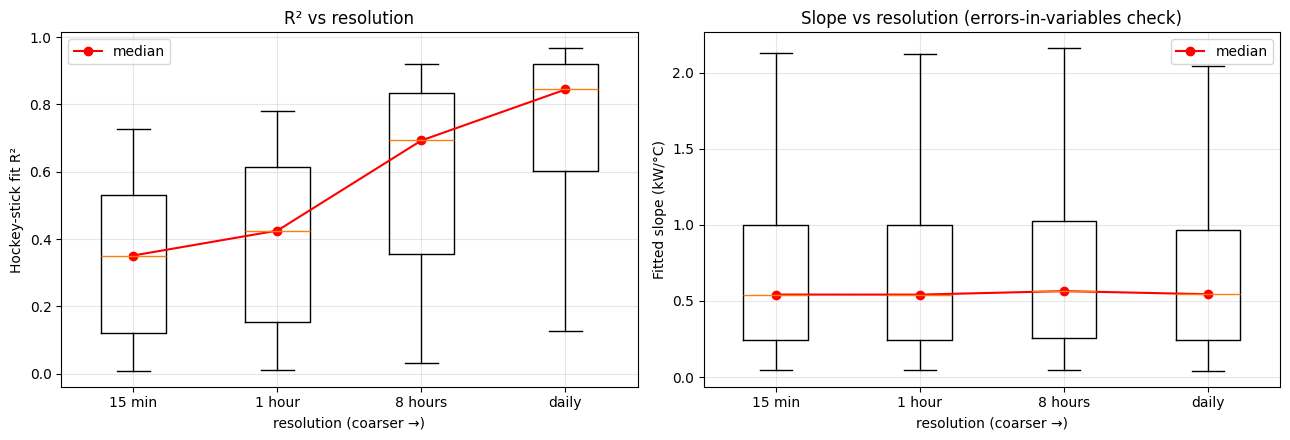


RESULT: R2 rises ~2.4x from 15 min to daily while the median slope moves
<1%. The errors-in-variables prediction is NOT borne out, so the R2 gain
comes from variance reduction in the RESPONSE, not from de-attenuating the
regressor -- i.e. it is the mechanical effect flagged above.

This is expected here for a concrete reason: the 15-min temperature is an
exact linear interpolation of HOURLY weather data (verified to 3e-6 °C), so
it carries no genuine sub-hourly variation and there is no sub-hourly
regressor noise for averaging to remove. The 15 min vs 1 h contrast is
therefore weaker evidence than the 8 h and daily contrasts.


In [13]:
# --- 3c: does the fitted SLOPE drift upward too? --------------------------
# If coarsening mainly removed noise from the REGRESSOR, attenuation bias would
# fall and the slope would rise with R2. Restricted to substations with heat
# pumps, where a slope is physically meaningful.
ok = h2_fits[~h2_fits.failed]
hp_only = ok[ok.N_hp > 0]
tab = hp_only.groupby('resolution')[['slope', 'r2']].median().reindex(h2.LABELS)
tab['slope_rel_15min'] = (tab.slope / tab.slope.iloc[0]).round(3)
tab['r2_rel_15min'] = (tab.r2 / tab.r2.iloc[0]).round(3)
print('median slope and R2 by resolution (substations with heat pumps):')
print(tab.round(4).to_string())

fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
pos = range(len(h2.LABELS))
axs[0].boxplot([hp_only[hp_only.resolution == l].r2 for l in h2.LABELS],
               labels=h2.LABELS, showfliers=False)
axs[0].plot([p + 1 for p in pos], tab.r2, 'o-', color='red', label='median')
axs[0].set_ylabel('Hockey-stick fit R²'); axs[0].set_title('R² vs resolution')
axs[0].set_xlabel('resolution (coarser →)'); axs[0].grid(alpha=.3); axs[0].legend()

axs[1].boxplot([hp_only[hp_only.resolution == l].slope for l in h2.LABELS],
               labels=h2.LABELS, showfliers=False)
axs[1].plot([p + 1 for p in pos], tab.slope, 'o-', color='red', label='median')
axs[1].set_ylabel('Fitted slope (kW/°C)')
axs[1].set_title('Slope vs resolution (errors-in-variables check)')
axs[1].set_xlabel('resolution (coarser →)'); axs[1].grid(alpha=.3); axs[1].legend()
fig.tight_layout(); plt.show()

print('\nRESULT: R2 rises ~2.4x from 15 min to daily while the median slope moves')
print('<1%. The errors-in-variables prediction is NOT borne out, so the R2 gain')
print('comes from variance reduction in the RESPONSE, not from de-attenuating the')
print('regressor -- i.e. it is the mechanical effect flagged above.')
print('\nThis is expected here for a concrete reason: the 15-min temperature is an')
print('exact linear interpolation of HOURLY weather data (verified to 3e-6 °C), so')
print('it carries no genuine sub-hourly variation and there is no sub-hourly')
print('regressor noise for averaging to remove. The 15 min vs 1 h contrast is')
print('therefore weaker evidence than the 8 h and daily contrasts.')


## Data collapse — is fit quality governed by `N_eff ∝ N · Δt`?

Spatial aggregation (more households) and temporal averaging (coarser Δt)
both reduce estimator variance. If they do so by the *same* mechanism, fit
quality should depend only on the product `N · Δt`, and points from very
different `(N, Δt)` combinations sharing a product must fall on one curve.

**Which `N`?** The heat-pump *signal* averages over the `N_hp` cycling units
while the *noise* averages over all `N_total` households, so which product
collapses better is itself a result. Both are fitted with the same functional
form on the same rows and compared by residual spread.

This section uses the **re-spaced collapse design** (`N ∈ {4, 8, 16, 27}`).
The main design realises only `N ∈ {5, 10, 20}`, which yields a single
`(N_total, Δt)` coincidence — not enough to test the law. The overlap check
below is cheap and gates the figure, so it runs first.

Slope CIs use **HAC (Newey–West)** standard errors: residuals are strongly
autocorrelated, and naive OLS errors understate slope uncertainty by up to
~2.3× at 15 min — which would flatter exactly the end of the trade-off being
plotted.

In [14]:
import hp_collapse as hc

# --- overlap check FIRST: without coincident products there is nothing to
# collapse and the figure cannot test the law.
for _col in ['N_total', 'N_hp']:
    hc.overlap_check(meta_collapse, _col)
    print()

collapse_fits = hc.fit_collapse(design_collapse, rebuild=False)
collapse_ok = collapse_fits[(~collapse_fits.failed) & (collapse_fits.N_hp > 0)]
print(f'{len(collapse_fits)} fits, {int(collapse_fits.failed.sum())} failed')


N_total: 4 levels x 4 resolutions = 16 combinations, 15 distinct products, range 648x
  clusters with >=2 distinct (N, dt) pairs within 20%: 4
    [(4, '1 hour'), (16, '15 min')]
    [(27, '15 min'), (8, '1 hour')]
    [(27, '1 hour'), (4, '8 hours')]
    [(8, 'daily'), (27, '8 hours')]

N_hp: 11 levels x 4 resolutions = 44 combinations, 35 distinct products, range 1920x
  clusters with >=2 distinct (N, dt) pairs within 20%: 18
    [(1, '1 hour'), (4, '15 min')]
    [(6, '15 min'), (7, '15 min')]
    [(7, '15 min'), (2, '1 hour'), (8, '15 min')]
    [(12, '15 min'), (3, '1 hour'), (14, '15 min')]
    [(14, '15 min'), (16, '15 min'), (4, '1 hour')]
    [(16, '15 min'), (4, '1 hour'), (20, '15 min'), (6, '1 hour')]
    [(6, '1 hour'), (7, '1 hour'), (1, '8 hours'), (8, '1 hour')]
    [(12, '1 hour'), (14, '1 hour')]
    [(14, '1 hour'), (16, '1 hour'), (2, '8 hours')]
    [(16, '1 hour'), (2, '8 hours'), (20, '1 hour'), (3, '8 hours'), (1, 'daily')]
    [(6, '8 hours'), (2, 'daily'), (7,

In [15]:
# --- which product gives the tighter collapse? ----------------------------
collapse_res = {c: hc.collapse_quality(collapse_ok, c) for c in ['N_hp', 'N_total']}
for c, r in collapse_res.items():
    print(f'{c}*dt : residual SD={r["resid_sd"]:.4f}  IQR={r["resid_iqr"]:.4f}  '
          f'curve R2={r["curve_r2"]:.4f}  (n={r["n_rows"]})')
_best = min(collapse_res, key=lambda c: collapse_res[c]['resid_sd'])
_worst = 'N_total' if _best == 'N_hp' else 'N_hp'
print(f'\n=> TIGHTER COLLAPSE: {_best}*dt '
      f'({collapse_res[_best]["resid_sd"]:.3f} vs {collapse_res[_worst]["resid_sd"]:.3f}, '
      f'{collapse_res[_worst]["resid_sd"] / collapse_res[_best]["resid_sd"]:.2f}x tighter)')
print('   The HP signal averages over N_hp cycling units; that, not the total\n'
      '   household count, is what governs fit quality.')

print('\nPrecision trade-off (medians by resolution):')
print(collapse_ok.groupby('resolution')[['r2', 'ci_rel', 'n_points']]
      .median().reindex(hc.LABELS).round(4).to_string())


N_hp*dt : residual SD=0.8757  IQR=1.2038  curve R2=0.6875  (n=3200)
N_total*dt : residual SD=1.3289  IQR=2.1024  curve R2=0.2804  (n=3200)

=> TIGHTER COLLAPSE: N_hp*dt (0.876 vs 1.329, 1.52x tighter)
   The HP signal averages over N_hp cycling units; that, not the total
   household count, is what governs fit quality.

Precision trade-off (medians by resolution):
                r2  ci_rel  n_points
resolution                          
15 min      0.2896  0.0397   35040.0
1 hour      0.3689  0.0484    8760.0
8 hours     0.6405  0.0613    1095.0
daily       0.8120  0.0852     365.0


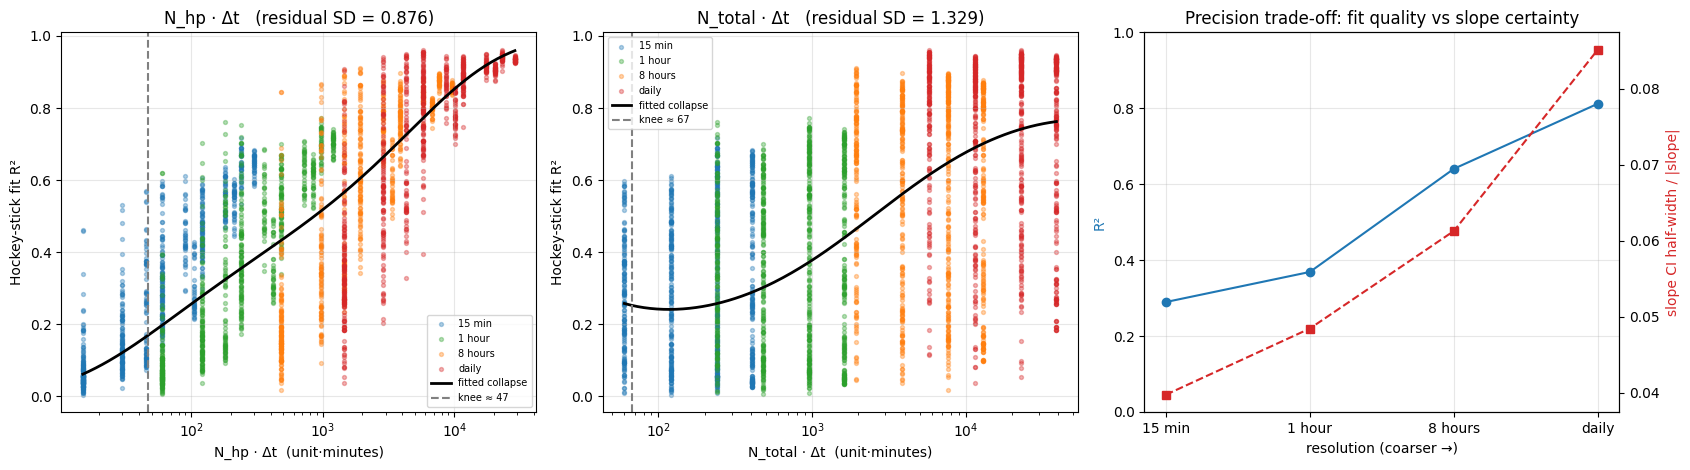

Coarsening raises R² but widens the slope CI (fewer samples), so the
useful operating point is a trade-off, not "as coarse as possible".


In [16]:
# --- the collapse figure --------------------------------------------------
fig, axs = plt.subplots(1, 3, figsize=(17, 4.8))
colours = dict(zip(hc.LABELS, ['tab:blue', 'tab:green', 'tab:orange', 'tab:red']))

for ax, col in zip(axs[:2], ['N_hp', 'N_total']):
    r = collapse_res[col]; d = r['data']
    for lab in hc.LABELS:
        s = d[d.resolution == lab]
        ax.scatter(s.neff, s.r2, s=8, alpha=.35, color=colours[lab], label=lab)
    xs = np.linspace(d.log_neff.min(), d.log_neff.max(), 200)
    from scipy.special import expit
    ax.plot(np.exp(xs), expit(np.polyval(r['coef'], xs)), 'k-', lw=2,
            label='fitted collapse')
    knee = hc.find_knee(r['coef'], d.log_neff.min(), d.log_neff.max())
    ax.axvline(knee, color='grey', ls='--', label=f'knee ≈ {knee:,.0f}')
    ax.set_xscale('log'); ax.set_xlabel(f'{col} · Δt  (unit·minutes)')
    ax.set_ylabel('Hockey-stick fit R²')
    ax.set_title(f'{col} · Δt   (residual SD = {r["resid_sd"]:.3f})')
    ax.grid(alpha=.3); ax.legend(fontsize=7)

# precision trade-off: R2 improves with coarser dt, slope CI widens
t = collapse_ok.groupby('resolution')[['r2', 'ci_rel']].median().reindex(hc.LABELS)
ax = axs[2]; pos = np.arange(len(hc.LABELS))
ax.plot(pos, t.r2, 'o-', color='tab:blue', label='median R²')
ax.set_ylabel('R²', color='tab:blue'); ax.set_ylim(0, 1)
ax2 = ax.twinx()
ax2.plot(pos, t.ci_rel, 's--', color='tab:red', label='relative slope CI')
ax2.set_ylabel('slope CI half-width / |slope|', color='tab:red')
ax.set_xticks(pos); ax.set_xticklabels(hc.LABELS)
ax.set_xlabel('resolution (coarser →)')
ax.set_title('Precision trade-off: fit quality vs slope certainty')
ax.grid(alpha=.3)
fig.tight_layout(); plt.show()

print('Coarsening raises R² but widens the slope CI (fewer samples), so the')
print('useful operating point is a trade-off, not "as coarse as possible".')


## Summary — headline numbers

In [17]:
# Every headline number in one place, for pasting into a paper draft.
print('=' * 78)
print('DESIGN')
print('=' * 78)
print(f"  main design      : {len(meta)} substations, N_total in "
      f"{sorted(meta['N_total'].unique().tolist())}, "
      f"{int((meta.hp_ratio == 0).sum())} zero-penetration controls")
print(f"  collapse design  : {len(meta_collapse)} substations, N_total in "
      f"{sorted(meta_collapse['N_total'].unique().tolist())}")
print(f"  distinct households underlying BOTH designs: "
      f"{design['n_distinct_households_used']} of "
      f"{design['n_distinct_households_available']} available")
print('  -> substations are pseudo-replicates from a small household pool;')
print('     the effective sample size is far below the substation count.')

print('\n' + '=' * 78)
print('H1  threshold test (999 bootstrap reps, 30-day moving block, alpha=0.05)')
print('=' * 78)
_c = h1_nl[h1_nl.N_hp == 0]
_lo, _hi = h1.wilson(int(_c.reject.sum()), len(_c))
print(f'  control false-positive floor (N_hp==0): {_c.reject.mean():.3f} '
      f'[{_lo:.3f}, {_hi:.3f}]  (n={len(_c)})')
for nm, df_ in [('SF', h1_sf), ('net load', h1_nl)]:
    tab = h1.rejection_table(df_, 'hp_ratio')
    print(f'  {nm:9s} detection limit (>80% rejection): '
          f'{h1.detection_limit(tab)}')
    tb = df_.loc[df_.reject, "t_bal"].dropna()
    print(f'  {nm:9s} T_bal median {tb.median():.1f} °C '
          f'[IQR {tb.quantile(.25):.1f}-{tb.quantile(.75):.1f}]')

print('\n' + '=' * 78)
print('H2  resolution effect')
print('=' * 78)
_p = h2.page_test(h2_wide)
print(f'  Page L = {_p.statistic:.0f}, p = {_p.pvalue:.2e} (ordered alternative)')
_b, _lo, _hi, _ = h2.coef_ci(h2_fit)
print(f'  EFFECT SIZE  logit(R2) ~ log(dt): {_b:.4f} per e-fold '
      f'[95% CI {_lo:.4f}, {_hi:.4f}]')
print(f'  median R2: ' + ', '.join(f'{l}={h2_wide[l].median():.3f}' for l in h2.LABELS))
_hp = h2_fits[(~h2_fits.failed) & (h2_fits.N_hp > 0)]
_s = _hp.groupby('resolution').slope.median().reindex(h2.LABELS)
print(f'  median slope: ' + ', '.join(f'{l}={_s[l]:.3f}' for l in h2.LABELS))
print('  -> R2 rises ~2.4x while the slope moves <1%: the gain is response-variance')
print('     reduction, NOT regressor de-attenuation. Note the 15-min temperature is')
print('     an exact linear interpolation of hourly data, so it has no genuine')
print('     sub-hourly content and the 15min-vs-1h contrast is weak evidence.')

print('\n' + '=' * 78)
print('DATA COLLAPSE')
print('=' * 78)
for c, r in collapse_res.items():
    _d = r['data']
    print(f'  {c}*dt : residual SD={r["resid_sd"]:.3f}, curve R2={r["curve_r2"]:.3f}, '
          f'knee at {hc.find_knee(r["coef"], _d.log_neff.min(), _d.log_neff.max()):,.0f} unit-min')
print(f'  -> {_best}*dt collapses '
      f'{collapse_res[_worst]["resid_sd"] / collapse_res[_best]["resid_sd"]:.2f}x tighter')
print('\nAll p-values are supporting checks; lead with the effect sizes and CIs above.')


DESIGN
  main design      : 840 substations, N_total in [5, 10, 20], 120 zero-penetration controls
  collapse design  : 1080 substations, N_total in [4, 8, 16, 27]
  distinct households underlying BOTH designs: 54 of 58 available
  -> substations are pseudo-replicates from a small household pool;
     the effective sample size is far below the substation count.

H1  threshold test (999 bootstrap reps, 30-day moving block, alpha=0.05)
  control false-positive floor (N_hp==0): 0.167 [0.125, 0.219]  (n=240)
  SF        detection limit (>80% rejection): 0.1
  SF        T_bal median 16.1 °C [IQR 15.3-16.7]
  net load  detection limit (>80% rejection): 0.25
  net load  T_bal median 16.3 °C [IQR 15.6-17.1]

H2  resolution effect
  Page L = 25118, p = 0.00e+00 (ordered alternative)
  EFFECT SIZE  logit(R2) ~ log(dt): 0.4903 per e-fold [95% CI 0.4833, 0.4972]
  median R2: 15 min=0.168, 1 hour=0.213, 8 hours=0.438, daily=0.664
  median slope: 15 min=0.542, 1 hour=0.541, 8 hours=0.564, daily=0.54

# Cross-dataset validation and the electric-heating confound

Everything above uses the HEAPO submetered cohort. Two further datasets are
brought in here, run through the **same** design generator and the **same**
H1/H2 tests, so any difference is a property of the data, not of the method.

| dataset | role | why |
|---|---|---|
| **HEAPO** | primary | Swiss, submetered HP + non-HP load |
| **Swiss** | complement | 1644 consumers lifts the `N_total` ceiling from 20 to 200 |
| **WPUQ** | independent validation | German: different climate, households, metering chain |

## Heat pumps are not the only temperature-driven electric load

A `hp_ratio = 0` substation is a true control only if it contains **no electric
heating at all**. Electric water heaters, storage heating and direct heating are
all electric loads that vary with the weather. Each dataset is therefore run in
two arms wherever the metadata allows:

* **`_clean`** — every non-HP member is free of electric heating of any kind.
* **`_eheat`** — every non-HP member *has* other electric heating, isolating its
  influence on an otherwise identical grid.

For the Swiss data only **households** are used (`Apartment`, `Single-family
house`); common areas, underground garages, elevators and feed-in systems are
building infrastructure with a different load signature and are excluded. The
only equipment paired to a dwelling there is the heat pump itself, which is what
provides `HP_Peak` ground truth.

WPUQ carries no appliance metadata, so only its clean arm exists — its households
may contain unflagged electric heating, which is stated rather than assumed away.

In [18]:
import hp_multi as hm

# ---------------------------------------------------------------------------
# Regeneration flags. All False = load everything from cache (instant).
#   REBUILD_POOLS      re-reads raw data: HEAPO ~7 min (1408 households),
#                      Swiss ~10 min (7.4 GB of CSVs), WPUQ seconds.
#   REGENERATE_DESIGNS re-draws the factorial designs from the pools.
#   RERUN_TESTS        re-runs H1 (999 bootstrap replicates) and H2.
# ---------------------------------------------------------------------------
REBUILD_POOLS = False
REGENERATE_DESIGNS = False
RERUN_TESTS = False

results = hm.run_all(rebuild_pool=REBUILD_POOLS,
                     regenerate_design=REGENERATE_DESIGNS,
                     rerun_tests=RERUN_TESTS)
print(f'\narms: {list(results)}')


[heapo_clean] loaded design (560 substations)
[heapo_eheat] loaded design (600 substations)
[swiss_clean] loaded design (920 substations)
[swiss_eheat] loaded design (920 substations)
[wpuq] loaded design (1120 substations)

arms: ['heapo_clean', 'heapo_eheat', 'swiss_clean', 'swiss_eheat', 'wpuq']


In [19]:
# Headline numbers per arm. control_rate is the false-positive floor: the share
# of substations with NO heat pumps where the threshold test still rejects.
# Every other number must be read against it, not against alpha.
summary = hm.summary_table(results)
print(summary.round(3).to_string(index=False))


        arm  n_sub  control_n  control_rate  control_lo  control_hi  sf_detect  nl_detect  log_dt  log_dt_lo  log_dt_hi  r2_ratio  slope_ratio
heapo_clean    560        200         0.275       0.218       0.341       0.10       0.25   0.490      0.475      0.505     4.552        1.017
heapo_eheat    600        200         0.025       0.011       0.057       0.10       0.50   0.395      0.381      0.409     5.054        0.975
swiss_clean    920        360         0.517       0.465       0.568       0.05       0.25   0.642      0.626      0.659     4.382        1.020
swiss_eheat    920        360         0.922       0.890       0.946       0.05       0.05   0.642      0.631      0.653     2.684        0.893
       wpuq   1120        280         0.150       0.113       0.197       0.05       0.25   0.571      0.555      0.587     3.542        1.154


In [20]:
# Influence of OTHER electric heating: identical grids, the only difference
# being whether the non-HP members have electric water heating / storage /
# direct heating.
for base in ['heapo', 'swiss']:
    a, b = f'{base}_clean', f'{base}_eheat'
    if a not in results or b not in results:
        continue
    print(f'--- {base.upper()} ---')
    for arm in (a, b):
        nl = results[arm][1]
        nl = nl[nl.response == 'NetLoad']
        c = nl[nl.N_hp == 0]
        lo, hi = h1.wilson(int(c.reject.sum()), len(c))
        print(f'  {arm:14s} control floor = {c.reject.mean():.3f} '
              f'[{lo:.3f}, {hi:.3f}]  (n={len(c)})')
    print()


--- HEAPO ---
  heapo_clean    control floor = 0.275 [0.218, 0.341]  (n=200)
  heapo_eheat    control floor = 0.025 [0.011, 0.057]  (n=200)

--- SWISS ---
  swiss_clean    control floor = 0.517 [0.465, 0.568]  (n=360)
  swiss_eheat    control floor = 0.922 [0.890, 0.946]  (n=360)



In [21]:
# Electric heating is not one thing. Split the Swiss pool by TYPE: electric
# SPACE heating (storage/direct) vs primary electric WATER heating.
eheat_types = hm.eheat_type_analysis()
print(eheat_types.to_string())
print()
print('Electric SPACE heating defeats the net-load test outright: controls reject')
print('at every size. Primary electric WATER heating is only weakly seasonal (via')
print('inlet water temperature) so it raises the floor more gently, but still')
print('reaches 1.0 by N=50.')
print()
print('HEAPO runs the other way: its electric water heaters are auxiliary elements')
print('in homes whose hot water is made by the heat pump, so they add temperature-')
print('INDEPENDENT noise and MASK the weak signal -- floor 0.025 for its _eheat arm')
print('versus 0.275 for _clean. Same flag name, opposite effect: what matters is')
print('whether the extra load is itself temperature-driven.')


Swiss other-electric-heating pool: 75 with space heating, 254 with water heating only
         space_heating  water_heating_only
N_total                                   
5                  1.0                0.60
10                 1.0                0.75
20                 1.0                0.95
50                 1.0                1.00

Electric SPACE heating defeats the net-load test outright: controls reject
at every size. Primary electric WATER heating is only weakly seasonal (via
inlet water temperature) so it raises the floor more gently, but still
reaches 1.0 by N=50.

HEAPO runs the other way: its electric water heaters are auxiliary elements
in homes whose hot water is made by the heat pump, so they add temperature-
INDEPENDENT noise and MASK the weak signal -- floor 0.025 for its _eheat arm
versus 0.275 for _clean. Same flag name, opposite effect: what matters is
whether the extra load is itself temperature-driven.


         heapo_clean  heapo_eheat  swiss_clean  swiss_eheat   wpuq
N_total                                                           
4                NaN          NaN          NaN          NaN  0.192
5              0.325        0.042        0.125        0.825    NaN
8                NaN          NaN          NaN          NaN  0.150
10             0.200        0.000        0.400        0.912    NaN
16               NaN          NaN          NaN          NaN  0.175
20               NaN          NaN        0.650        1.000    NaN
32               NaN          NaN          NaN          NaN  0.000
50               NaN          NaN        0.875        1.000    NaN
100              NaN          NaN        0.950        1.000    NaN
200              NaN          NaN        1.000        1.000    NaN


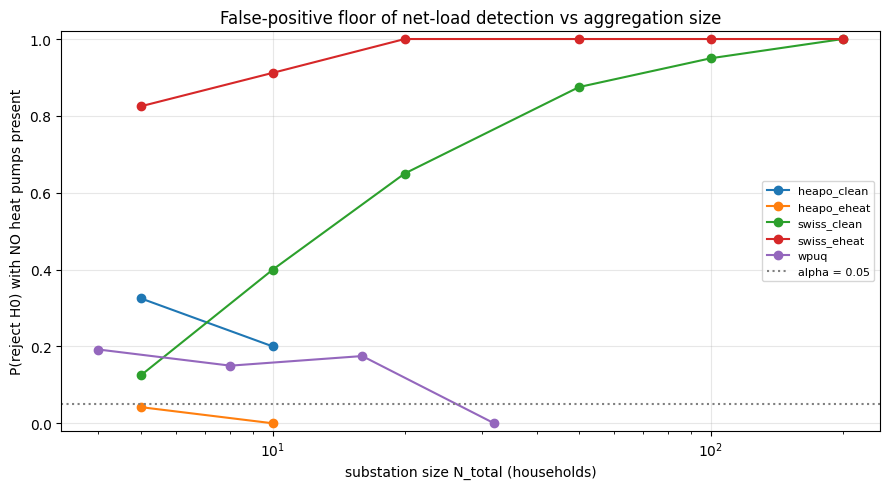

In [22]:
# The result that matters for deployment: the control floor is not a constant.
# Non-HP dwellings are not temperature-inert -- a gas- or oil-heated home still
# runs circulation pumps and controls in winter. Aggregating more of them
# averages away noise, so the test gains POWER to detect that small real signal
# and the false-positive floor RISES with substation size.
floor = hm.control_floor_table(results)
print(floor.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
for arm in floor.columns:
    s = floor[arm].dropna()
    ax.plot(s.index, s.values, 'o-', label=arm)
ax.axhline(ALPHA, color='grey', ls=':', label=f'alpha = {ALPHA}')
ax.set_xscale('log')
ax.set_xlabel('substation size N_total (households)')
ax.set_ylabel('P(reject H0) with NO heat pumps present')
ax.set_title('False-positive floor of net-load detection vs aggregation size')
ax.set_ylim(-0.02, 1.02); ax.grid(alpha=.3); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()


In [23]:
# H2 replication: same direction and comparable effect size in every arm.
cols = ['arm', 'n_sub', 'log_dt', 'log_dt_lo', 'log_dt_hi', 'r2_ratio', 'slope_ratio']
print(summary[cols].round(3).to_string(index=False))
print()
print(f"H2 direction holds in {int((summary.log_dt > 0).sum())}/{len(summary)} arms; "
      f"slope ratio within 0.8-1.25 in "
      f"{int(summary.slope_ratio.between(0.8, 1.25).sum())}/{len(summary)}.")
print('R2 rises 2.7-5x while the slope barely moves: the gain is response-variance')
print('reduction, not regressor de-attenuation. WPUQ is the partial exception --')
print('its weather is natively 5-minute, whereas HEAPO and Swiss temperatures are')
print('exact hourly interpolations with no sub-hourly regressor noise to remove,')
print('which is why only WPUQ shows a slope drift (1.15x).')


        arm  n_sub  log_dt  log_dt_lo  log_dt_hi  r2_ratio  slope_ratio
heapo_clean    560   0.490      0.475      0.505     4.552        1.017
heapo_eheat    600   0.395      0.381      0.409     5.054        0.975
swiss_clean    920   0.642      0.626      0.659     4.382        1.020
swiss_eheat    920   0.642      0.631      0.653     2.684        0.893
       wpuq   1120   0.571      0.555      0.587     3.542        1.154

H2 direction holds in 5/5 arms; slope ratio within 0.8-1.25 in 5/5.
R2 rises 2.7-5x while the slope barely moves: the gain is response-variance
reduction, not regressor de-attenuation. WPUQ is the partial exception --
its weather is natively 5-minute, whereas HEAPO and Swiss temperatures are
exact hourly interpolations with no sub-hourly regressor noise to remove,
which is why only WPUQ shows a slope drift (1.15x).


### What the extra datasets change

1. **H2 replicates everywhere.** `log_dt` is positive with comparable magnitude in
   all five arms and the fitted slope stays flat while R² rises several-fold. The
   resolution effect is a property of the estimator, not of one dataset.

2. **The SF test is robust.** It uses the submetered HP series directly, so no
   amount of other electric heating in the surrounding households can touch it.

3. **The net-load test has two independent limits.** Other electric heating shifts
   the false-positive floor at fixed size — upward when that load is itself
   temperature-driven (space heating: floor = 1.0 at every size), downward when it
   is not (HEAPO's auxiliary water heaters mask the signal). And the floor rises
   with aggregation regardless, because non-HP load is genuinely, weakly
   temperature-dependent and larger `N` gives the test more power to find it.
   By `N = 200` it reaches 1.0.

So the detection limits reported earlier hold **at small aggregation only** and
should always be quoted with the substation size attached. At feeder scale the
net-load threshold test cannot separate heat pumps from ordinary winter
electricity use. Only the Swiss arm can show this: HEAPO and WPUQ stop at
`N <= 20/32`, and their controls are synthetic rather than real non-HP households.